# NBA Game Outcome Prediction Pipeline

### Inspecting the columns

In [33]:
#logging setup
import logging

logging.basicConfig(
    filename='pipeline.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

logging.info("Pipeline started")

In [ ]:
import pandas as pd

#raw data files
team_raw = pd.read_csv("/Users/leahkim/Desktop/project1-sports-outcomes/raw/team.csv")
game_raw = pd.read_csv("/Users/leahkim/Desktop/project1-sports-outcomes/raw/game.csv")
line_score_raw = pd.read_csv("/Users/leahkim/Desktop/project1-sports-outcomes/raw/line_score.csv")

print("team.csv columns:")
print(team_raw.columns.tolist())
print()

print("game.csv columns:")
print(game_raw.columns.tolist())
print()

print("line_score.csv columns:")
print(line_score_raw.columns.tolist())

team.csv columns:
['id', 'full_name', 'abbreviation', 'nickname', 'city', 'state', 'year_founded']

game.csv columns:
['season_id', 'team_id_home', 'team_abbreviation_home', 'team_name_home', 'game_id', 'game_date', 'matchup_home', 'wl_home', 'min', 'fgm_home', 'fga_home', 'fg_pct_home', 'fg3m_home', 'fg3a_home', 'fg3_pct_home', 'ftm_home', 'fta_home', 'ft_pct_home', 'oreb_home', 'dreb_home', 'reb_home', 'ast_home', 'stl_home', 'blk_home', 'tov_home', 'pf_home', 'pts_home', 'plus_minus_home', 'video_available_home', 'team_id_away', 'team_abbreviation_away', 'team_name_away', 'matchup_away', 'wl_away', 'fgm_away', 'fga_away', 'fg_pct_away', 'fg3m_away', 'fg3a_away', 'fg3_pct_away', 'ftm_away', 'fta_away', 'ft_pct_away', 'oreb_away', 'dreb_away', 'reb_away', 'ast_away', 'stl_away', 'blk_away', 'tov_away', 'pf_away', 'pts_away', 'plus_minus_away', 'video_available_away', 'season_type']

line_score.csv columns:
['game_date_est', 'game_sequence', 'game_id', 'team_id_home', 'team_abbreviatio

### Create the Tables

In [35]:
import pandas as pd
from pathlib import Path

# Paths
RAW_DIR = Path("/Users/leahkim/Desktop/project1-sports-outcomes/raw/")
OUT_DIR = Path("/Users/leahkim/Desktop/project1-sports-outcomes/data")
OUT_DIR.mkdir(exist_ok=True)

try:
    logging.info("Starting data creation section")

    # Load raw files
    team_raw = pd.read_csv(RAW_DIR / "team.csv")
    game_raw = pd.read_csv(RAW_DIR / "game.csv")
    line_score_raw = pd.read_csv(RAW_DIR / "line_score.csv")
    logging.info("Raw files loaded successfully")

    print("Loaded raw files:")
    print("team.csv:", team_raw.shape)
    print("game.csv:", game_raw.shape)
    print("line_score.csv:", line_score_raw.shape)

    # 1. Create teams table
    teams = team_raw.rename(columns={
        "id": "team_id",
        "full_name": "team_name"
    })[
        ["team_id", "team_name", "abbreviation", "nickname", "city", "state", "year_founded"]
    ].drop_duplicates()
    logging.info("Teams table created")

    # 2. Create seasons table
    seasons = game_raw[["season_id", "season_type"]].drop_duplicates().copy()
    seasons["season_year"] = seasons["season_id"]
    seasons = seasons[["season_id", "season_year", "season_type"]]
    logging.info("Seasons table created")

    # 3. Create games table
    games = game_raw.rename(columns={
        "team_id_home": "home_team_id",
        "team_id_away": "away_team_id",
        "pts_home": "home_score",
        "pts_away": "away_score"
    })[
        ["game_id", "game_date", "season_id", "season_type", "home_team_id", "away_team_id", "home_score", "away_score"]
    ].drop_duplicates(subset=["game_id"]).copy()

    games["winner_team_id"] = games.apply(
        lambda row: row["home_team_id"] if row["home_score"] > row["away_score"] else row["away_team_id"],
        axis=1
    )
    logging.info("Games table created")

    # 4. Create team_game_stats table
    home_stats = game_raw[[
        "game_id", "team_id_home", "fg_pct_home", "ft_pct_home", "fg3_pct_home",
        "ast_home", "reb_home", "tov_home", "pts_home", "wl_home"
    ]].copy()

    home_stats = home_stats.rename(columns={
        "team_id_home": "team_id",
        "fg_pct_home": "fg_pct",
        "ft_pct_home": "ft_pct",
        "fg3_pct_home": "fg3_pct",
        "ast_home": "ast",
        "reb_home": "reb",
        "tov_home": "tov",
        "pts_home": "pts",
        "wl_home": "wl"
    })

    away_stats = game_raw[[
        "game_id", "team_id_away", "fg_pct_away", "ft_pct_away", "fg3_pct_away",
        "ast_away", "reb_away", "tov_away", "pts_away", "wl_away"
    ]].copy()

    away_stats = away_stats.rename(columns={
        "team_id_away": "team_id",
        "fg_pct_away": "fg_pct",
        "ft_pct_away": "ft_pct",
        "fg3_pct_away": "fg3_pct",
        "ast_away": "ast",
        "reb_away": "reb",
        "tov_away": "tov",
        "pts_away": "pts",
        "wl_away": "wl"
    })

    team_game_stats = pd.concat([home_stats, away_stats], ignore_index=True)
    team_game_stats = team_game_stats.drop_duplicates(subset=["game_id", "team_id"])
    team_game_stats["win_flag"] = team_game_stats["wl"].map({"W": 1, "L": 0})
    team_game_stats.insert(0, "team_game_stats_id", range(1, len(team_game_stats) + 1))
    team_game_stats = team_game_stats[
        ["team_game_stats_id", "game_id", "team_id", "fg_pct", "ft_pct", "fg3_pct", "ast", "reb", "tov", "pts", "win_flag"]
    ]
    logging.info("Team game stats table created")

    # Save outputs
    teams.to_csv(OUT_DIR / "teams.csv", index=False)
    seasons.to_csv(OUT_DIR / "seasons.csv", index=False)
    games.to_csv(OUT_DIR / "games.csv", index=False)
    team_game_stats.to_csv(OUT_DIR / "team_game_stats.csv", index=False)

    # Save Parquet too
    teams.to_parquet(OUT_DIR / "teams.parquet", index=False)
    seasons.to_parquet(OUT_DIR / "seasons.parquet", index=False)
    games.to_parquet(OUT_DIR / "games.parquet", index=False)
    team_game_stats.to_parquet(OUT_DIR / "team_game_stats.parquet", index=False)

    logging.info("All output files saved successfully")

    print("\nCreated tables:")
    print("teams:", teams.shape)
    print("seasons:", seasons.shape)
    print("games:", games.shape)
    print("team_game_stats:", team_game_stats.shape)

except Exception as e:
    logging.exception("Data creation section failed")
    print(f"Error during data creation: {e}")

Loaded raw files:
team.csv: (30, 7)
game.csv: (65698, 55)
line_score.csv: (58053, 43)

Created tables:
teams: (30, 7)
seasons: (281, 3)
games: (65642, 9)
team_game_stats: (131284, 11)


### Relational Model Note

The full relational schema was created to organize the data in a normalized and reusable form. Although the initial predictive model uses primarily the `team_game_stats` table, the `teams`, `games`, and `seasons` tables provide important context, support the metadata requirements of the project, and create a foundation for future feature engineering such as home-court advantage, seasonal effects, and team-level comparisons.

## Data Preparation

The structured dataset was loaded into a DuckDB database using Python to enable efficient querying and analysis. DuckDB allows SQL queries to be executed directly on local data files, making it well suited for analytical workflows.

The data tables, including `teams`, `games`, `seasons`, and `team_game_stats`, were imported into DuckDB as relational tables. This step organizes the data into a database format that supports structured queries and ensures consistency across the analysis pipeline.

Using DuckDB provides a clear separation between raw data storage and analytical processing. Instead of working directly with raw files, the data is first loaded into a database environment and then queried to produce a clean dataset for modeling.

This approach reflects a realistic data science workflow, where data is stored in a relational database and accessed through SQL before being used in machine learning models.

In [36]:
import duckdb

# Connect to DuckDB
con = duckdb.connect()

# Load all relational tables into DuckDB
con.execute("CREATE OR REPLACE TABLE teams AS SELECT * FROM teams")
con.execute("CREATE OR REPLACE TABLE seasons AS SELECT * FROM seasons")
con.execute("CREATE OR REPLACE TABLE games AS SELECT * FROM games")
con.execute("CREATE OR REPLACE TABLE team_game_stats AS SELECT * FROM team_game_stats")

# Preview one table
con.execute("SELECT * FROM team_game_stats LIMIT 5").df()

logging.info("All tables loaded into DuckDB")

## Data Query

This step selects relevant features that are expected to influence game outcomes.

In [37]:
query = """
SELECT 
    fg_pct,
    ft_pct,
    fg3_pct,
    ast,
    reb,
    tov,
    win_flag
FROM team_game_stats
"""

df_model = con.execute(query).df()
df_model.head()
print(df_model.isnull().sum())

fg_pct      30979
ft_pct       6014
fg3_pct     37991
ast         31606
reb         31454
tov         37327
win_flag        4
dtype: int64


### Missing Data Handling

The dataset contained a significant number of missing values across several performance variables such as field goal percentage, assists, and turnovers. Removing all rows with missing values would have resulted in a substantial loss of data and reduced the reliability of the model. 

To address this, missing values in numerical features were imputed using the mean of each column. This approach preserves the overall dataset size while maintaining reasonable estimates for missing entries. 

Rows with missing target values (win_flag) were removed, since the model requires a known outcome for training.

In [38]:
# Remove rows where target is missing
df_model = df_model.dropna(subset=["win_flag"])

# Fill missing values in features
feature_cols = ["fg_pct", "ft_pct", "fg3_pct", "ast", "reb", "tov"]
df_model[feature_cols] = df_model[feature_cols].fillna(df_model[feature_cols].mean())

# Ensure target is binary
df_model["win_flag"] = df_model["win_flag"].astype(int)

## Model Implementation

A logistic regression model is used to predict the probability of a team winning a game based on performance statistics.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Separate features (X) and target variable (y)
# X contains all predictor variables, y is the win/loss outcome
X = df_model.drop("win_flag", axis=1)
y = df_model["win_flag"]

# Split the data into training and testing sets
# 80% for training, 20% for testing the model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Initialize the logistic regression model
# max_iter is increased to ensure the model converges
model = LogisticRegression(max_iter=1000)

# Train the model using the training data
model.fit(X_train, y_train)

# Evaluate the model using the test data
# This returns the accuracy (percentage of correct predictions)
accuracy = model.score(X_test, y_test)

# Print the model accuracy
print("Model Accuracy:", accuracy)

# Log that the model training step completed successfully
logging.info("Model trained successfully")

Model Accuracy: 0.7129418037781841


## Model Improvement

The initial logistic regression model provided a strong baseline for predicting game outcomes. To improve performance, the input features were standardized, since logistic regression is sensitive to differences in scale across variables. This helped the model train more effectively and improved the reliability of the predictions.

To strengthen the analysis, additional evaluation metrics were considered beyond simple accuracy, including ROC AUC, a confusion matrix, and a classification report. These measures provide a more complete understanding of model performance by showing not only how often the model is correct, but also how well it separates wins from losses.

Hyperparameter tuning was also performed for logistic regression to test whether alternative settings could improve performance. In addition, a Random Forest model was evaluated as a more flexible comparison model. However, the Random Forest model did not outperform logistic regression, suggesting that the relationship between these team performance statistics and game outcomes is relatively structured and can be captured effectively by a simpler, more interpretable model.

Overall, this comparison shows that increasing model complexity does not always improve results, and that model selection should balance predictive performance, interpretability, and alignment with the project goal of estimating win probability.

In [ ]:
try:
    # Log the start of the model training process
    logging.info("Starting model training")

    # Import required libraries for modeling and evaluation
    from sklearn.model_selection import train_test_split, GridSearchCV
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
    import pandas as pd
    import matplotlib.pyplot as plt

    # Select feature columns used to predict game outcomes
    feature_cols = ["fg_pct", "ft_pct", "fg3_pct", "ast", "reb", "tov"]

    # Separate predictors (X) and target variable (y)
    X = df_model[feature_cols]
    y = df_model["win_flag"]

    # Split data into training and testing sets (80/20 split)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Standardize features for logistic regression (important for model performance)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train baseline logistic regression model
    # This model predicts win/loss and outputs probabilities
    log_model = LogisticRegression(max_iter=1000, C=1.0)
    log_model.fit(X_train_scaled, y_train)

    # Generate predictions and probabilities
    log_preds = log_model.predict(X_test_scaled)
    log_probs = log_model.predict_proba(X_test_scaled)[:, 1]

    # Evaluate baseline model performance
    log_accuracy = accuracy_score(y_test, log_preds)

    print("Baseline Logistic Regression Accuracy:", log_accuracy)
    print("Baseline Logistic Regression ROC AUC:", roc_auc_score(y_test, log_probs))

    # Define parameter grid for hyperparameter tuning
    # This tests different values of regularization strength and solver
    param_grid = {
        "C": [0.01, 0.1, 1, 10],
        "solver": ["lbfgs", "liblinear"]
    }

    # Perform grid search with cross-validation to find best model parameters
    grid = GridSearchCV(
        LogisticRegression(max_iter=1000),
        param_grid,
        cv=5,
        scoring="accuracy"
    )
    grid.fit(X_train_scaled, y_train)

    # Use the best model from grid search
    best_log_model = grid.best_estimator_

    # Evaluate tuned model
    best_preds = best_log_model.predict(X_test_scaled)
    best_probs = best_log_model.predict_proba(X_test_scaled)[:, 1]

    print("\nBest Logistic Parameters:", grid.best_params_)
    print("Tuned Logistic Accuracy:", accuracy_score(y_test, best_preds))
    print("Tuned Logistic ROC AUC:", roc_auc_score(y_test, best_probs))

    # Print detailed evaluation metrics
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, best_preds))
    print("\nClassification Report:\n", classification_report(y_test, best_preds))

    # Train a Random Forest model for comparison
    # This model can capture more complex, non-linear relationships
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)

    # Evaluate Random Forest model
    rf_preds = rf_model.predict(X_test)
    rf_accuracy = accuracy_score(y_test, rf_preds)

    print("Random Forest Accuracy:", rf_accuracy)

    # Log successful completion of modeling section
    logging.info("Model training and evaluation completed successfully")

except Exception as e:
    # Log error if anything fails during model training
    logging.exception("Model training section failed")
    print(f"Error during model training: {e}")

Baseline Logistic Regression Accuracy: 0.7074192565508836
Baseline Logistic Regression ROC AUC: 0.7983109691603172

Best Logistic Parameters: {'C': 0.01, 'solver': 'liblinear'}
Tuned Logistic Accuracy: 0.7077239488117002
Tuned Logistic ROC AUC: 0.7982609414518375

Confusion Matrix:
 [[9113 4156]
 [3518 9469]]

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.69      0.70     13269
           1       0.69      0.73      0.71     12987

    accuracy                           0.71     26256
   macro avg       0.71      0.71      0.71     26256
weighted avg       0.71      0.71      0.71     26256

Random Forest Accuracy: 0.7014015843997562


## Results Interpretation

The logistic regression model achieved an accuracy of approximately 71 percent, indicating that it correctly predicts game outcomes in most cases. More importantly, the model achieved a ROC AUC of approximately 0.80, which suggests that it is effective at distinguishing between winning and losing outcomes. This indicates that the model has strong predictive capability beyond simple accuracy.

Hyperparameter tuning did not significantly improve performance, suggesting that the baseline model was already well suited to the structure of the data. Additionally, a Random Forest model was tested but did not outperform logistic regression, reinforcing the conclusion that the relationships between team performance statistics and game outcomes are relatively linear.

The confusion matrix and classification report show that the model performs in a balanced way across both classes, with similar precision and recall for wins and losses. This indicates that the model does not strongly favor one outcome over the other.

The feature coefficients provide insight into which factors influence winning. Shooting percentages such as free throw percentage and three point percentage have positive effects, meaning higher values increase the probability of winning. In contrast, turnovers have a strong negative effect, indicating that teams that commit more turnovers are significantly less likely to win. These results align with real world expectations about basketball performance.

## Analysis Rationale

Logistic regression was selected as the primary model because this project focuses on a binary classification problem, whether a team wins or loses. It is well suited for this task because it is interpretable, computationally efficient, and directly produces probability estimates, which aligns with the goal of estimating win probability.

The selected features, including shooting percentages, assists, rebounds, and turnovers, were chosen because they reflect team performance in ways that are meaningfully related to game outcomes. These variables provide a clear baseline for evaluating whether in game statistical performance can help explain winning.

This approach applies supervised machine learning concepts covered in DS 3021/4021, where a model is trained to learn relationships between predictor variables and a known target outcome. Additional steps such as feature scaling, hyperparameter tuning, and comparison with a Random Forest model were included to strengthen the analysis and evaluate whether a more complex model would improve performance. The results showed that logistic regression remained the more appropriate choice because it performed slightly better while also being easier to interpret.

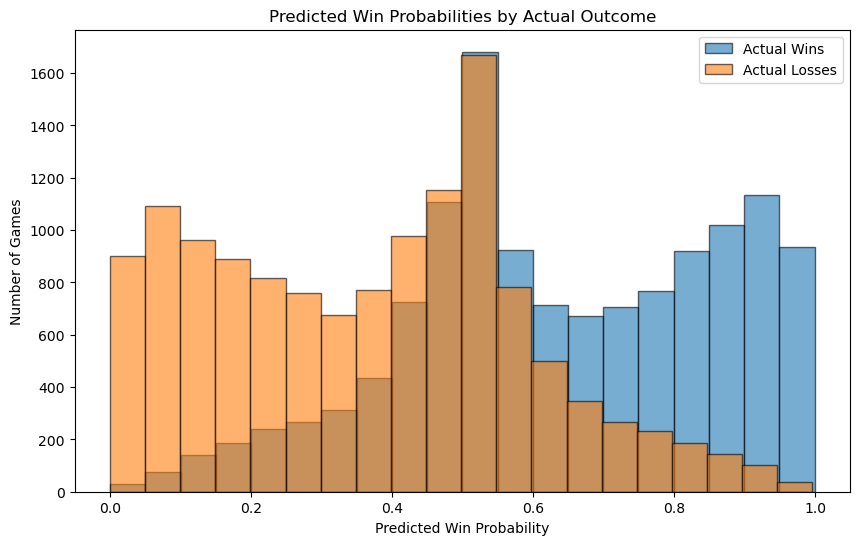

In [41]:
import matplotlib.pyplot as plt

# Get probabilities
probs = log_model.predict_proba(X_test_scaled)[:, 1]

# Separate by actual outcome
probs_win = probs[y_test == 1]
probs_loss = probs[y_test == 0]

plt.figure(figsize=(10, 6))

# Plot distributions
plt.hist(probs_win, bins=20, alpha=0.6, label="Actual Wins", edgecolor="black")
plt.hist(probs_loss, bins=20, alpha=0.6, label="Actual Losses", edgecolor="black")

plt.xlabel("Predicted Win Probability")
plt.ylabel("Number of Games")
plt.title("Predicted Win Probabilities by Actual Outcome")
plt.legend()

plt.show()

## Visualization Interpretation

This visualization compares the predicted win probabilities with the actual outcomes of the games. The distribution shows that games resulting in wins are generally associated with higher predicted probabilities, while losses tend to have lower predicted probabilities. This indicates that the model is able to meaningfully distinguish between winning and losing outcomes.

There is some overlap in the middle range of probabilities, around 0.4 to 0.6, which represents games where the model is less confident. This likely reflects closely matched teams or games where performance differences are not as pronounced.

Overall, the separation between the two distributions demonstrates that the model captures important relationships between team performance statistics and game outcomes, while still reflecting the inherent uncertainty in predicting sports results.

## Visualization Rationale

A histogram was used to visualize the distribution of predicted win probabilities generated by the logistic regression model. This type of visualization is appropriate because it shows how predictions are spread across the probability range from 0 to 1, making it easy to assess model confidence and behavior.

The distribution indicates that many predictions fall near 0.5, suggesting that the model often identifies games as relatively balanced. At the same time, predictions closer to 0 or 1 represent games where the model detects stronger differences in team performance.

This visualization helps interpret not only the accuracy of the model but also how confidently it makes predictions, which is important for understanding its practical usefulness.

## Does the Pipeline Solve the Problem?

The pipeline successfully addresses the problem by using team performance statistics to estimate the probability that a team will win a game. The logistic regression model achieved about 71 percent accuracy and a ROC AUC of about 0.80, showing that it can meaningfully distinguish between wins and losses. The results also show that variables such as shooting efficiency and turnovers are important predictors of game outcomes.

Although the model does not predict perfectly, it provides a useful baseline for understanding how team statistics relate to winning and for generating win probability scores. The overlap in predicted probabilities suggests that some games remain difficult to classify, which is expected in sports settings. Overall, the pipeline solves the problem at a baseline level and provides a strong foundation for future improvements through additional features and feature engineering.